# Customer Behavior Analysis

## Objective

To analyze customer transaction data and identify customer segments, purchasing patterns, payment preferences, and churn risks for business decision-making.

## Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Google Colab


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64


In [13]:
df['Returns'] = df['Returns'].fillna(0)

print(df.isnull().sum())

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64


In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 250000


In [16]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Year,Month
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,2020,9
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,2022,3
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,2022,5
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,2020,11
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,2020,11


## Customer Segmentation using RFM Analysis

RFM stands for:

- Recency: How recently a customer purchased
- Frequency: How often a customer purchases
- Monetary: How much a customer spends

Customers are classified into:
- Champions
- Regular
- At Risk

In [17]:
snapshot_date = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,49673.000000,49673.000000,49673.000000
mean,260.424979,5.032915,13716.559962
std,246.024001,2.206427,6840.208557
min,0.000000,1.000000,110.000000
25%,77.000000,3.000000,8719.000000
50%,184.000000,5.000000,13026.000000
75%,368.000000,6.000000,17966.000000
max,1352.000000,17.000000,55339.000000


In [19]:
rfm['Segment'] = 'Regular'

rfm.loc[
    (rfm['Frequency'] > rfm['Frequency'].median()) &
    (rfm['Monetary'] > rfm['Monetary'].median()),
    'Segment'
] = 'Champions'

rfm.loc[
    (rfm['Recency'] > rfm['Recency'].median()),
    'Segment'
] = 'At Risk'

rfm.head()

,Recency,Frequency,Monetary,Segment
Customer ID,,,,
1,57,1,3491,Regular
2,298,3,7988,At Risk
3,88,8,22587,Champions
4,126,4,8715,Regular
5,170,8,12524,Regular


In [20]:
rfm['Segment'].value_counts()

,count
Segment,
At Risk,24815
Regular,13392
Champions,11466


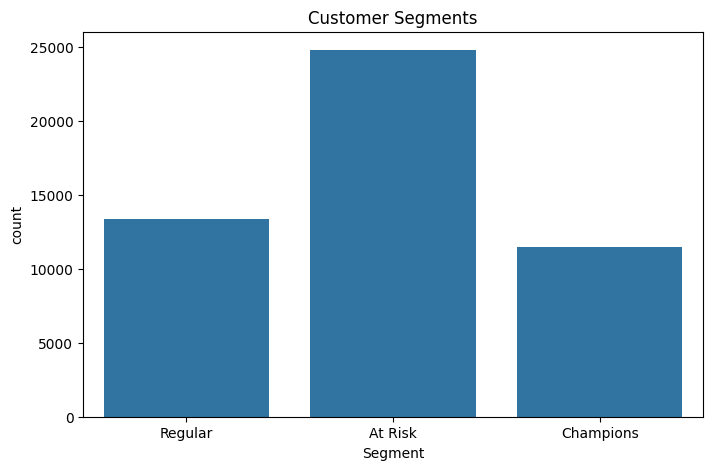

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(x='Segment', data=rfm.reset_index())

plt.title("Customer Segments")

plt.show()

In [22]:
top_categories = df['Product Category'].value_counts()

print(top_categories)

Product Category
Clothing       75052
Books          74912
Electronics    50185
Home           49851
Name: count, dtype: int64


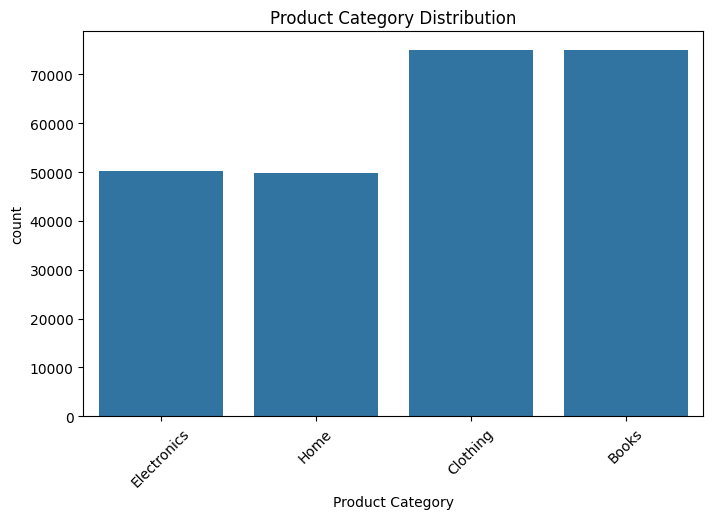

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(x='Product Category', data=df)

plt.title("Product Category Distribution")

plt.xticks(rotation=45)

plt.show()

In [24]:
print(df['Payment Method'].value_counts())

Payment Method
Credit Card    100486
PayPal          74837
Cash            49894
Crypto          24783
Name: count, dtype: int64


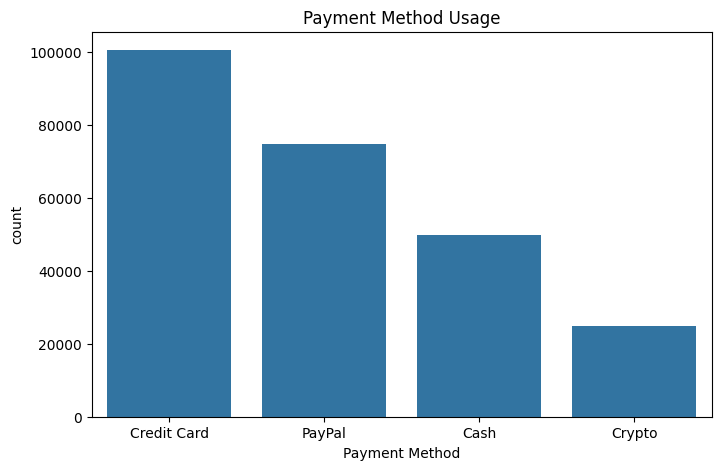

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(x='Payment Method', data=df)

plt.title("Payment Method Usage")

plt.show()

In [26]:
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

print(monthly_sales)

Month
1     62377969
2     57343030
3     63190828
4     59611906
5     62044880
6     60487756
7     62641624
8     62454400
9     52046626
10    46705059
11    45655744
12    46782861
Name: Total Purchase Amount, dtype: int64


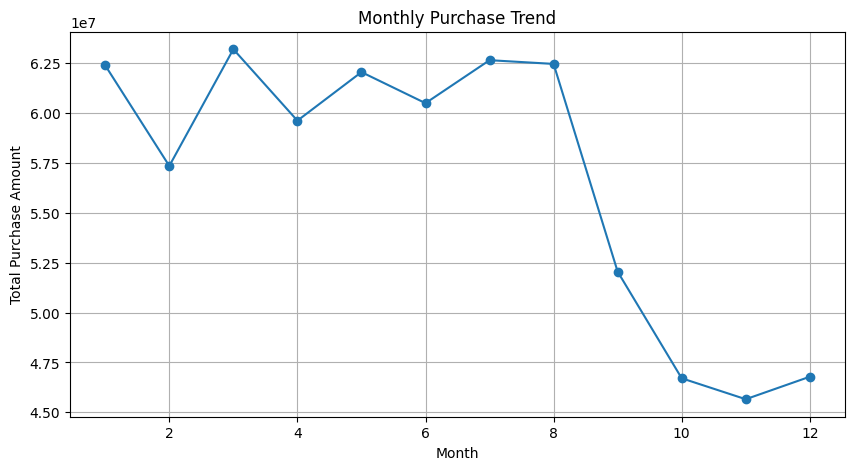

In [27]:
plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Purchase Trend")

plt.ylabel("Total Purchase Amount")

plt.grid(True)

plt.show()

In [28]:
print(df['Churn'].value_counts())

Churn
0    200126
1     49874
Name: count, dtype: int64


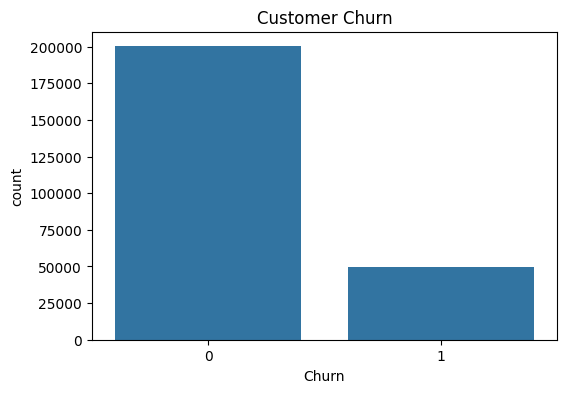

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn")

plt.show()

# Key Findings

1. At Risk customers are the largest customer segment.
2. Champions customers contribute high value purchases.
3. Clothing and Books are the most purchased categories.
4. Credit Card is the most preferred payment method.
5. Around 20% of customers have churned.
6. Sales vary across different months.

# Recommendations

1. Offer loyalty rewards to Champions customers.
2. Run special campaigns for At Risk customers.
3. Promote top-selling categories.
4. Improve customer retention strategies.
5. Launch offers during low-sales months.

# Conclusion

Customer segmentation and behavior analysis were successfully performed. The insights can help improve customer engagement, retention, and sales performance.